In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import joblib
import re
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import sys

from sklearn.model_selection import train_test_split
from plotly.subplots import make_subplots
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.feature_extraction.text import CountVectorizer   # Sac de mots
from sklearn.feature_extraction.text import TfidfVectorizer    # TF-IDF
from sklearn.feature_extraction.text import (
    ENGLISH_STOP_WORDS  #Stop words English
)
from sklearn.svm import LinearSVC
import pickle
import nltk
import shutil
import os
import glob
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.exceptions import ConvergenceWarning

# Librairies pour LDA
import gensim                    # Modélisation des topics et NLP
from gensim import corpora       # Création du dictionnaire de mots
from gensim.models import LdaModel  # Modèle LDA simple
from gensim.utils import simple_preprocess  # Prétraitement simple des textes
from gensim.models import CoherenceModel    # Calcul de la cohérence des topics
from gensim.models import Phrases           # Création de bigrammes/trigrammes
from gensim.models.phrases import Phraser   # Optimisation bigrammes/trigrammes
from gensim import corpora, models          # Utilisation des modèles
from gensim.models import LdaMulticore      # Modèle LDA parallèle
import multiprocessing                      # Gestion du multi-threading


nltk_data_dir = './nltk_data'


# On laisse au cas où
# # Aggressively clean corrupted NLTK data
# if os.path.exists(nltk_data_dir):
#     shutil.rmtree(nltk_data_dir)
# # Also remove any corrupted zip files from system paths
# for path in nltk.data.path:
#     if os.path.exists(path):
#         for zipfile in glob.glob(os.path.join(path, '*.zip')):
#             try:
#                 os.remove(zipfile)
#             except:
#                 pass

# Create fresh nltk_data directory
os.makedirs(nltk_data_dir, exist_ok=True)
nltk.data.path.insert(0, nltk_data_dir)

# Download resources with fresh start
print("Downloading NLTK resources...")
nltk.download('wordnet', download_dir=nltk_data_dir, quiet=True)
nltk.download('omw-1.4', download_dir=nltk_data_dir, quiet=True)
nltk.download('wordnet_ic', download_dir=nltk_data_dir, quiet=True)
nltk.download('averaged_perceptron_tagger', download_dir=nltk_data_dir, quiet=True)
print("NLTK resources downloaded successfully!")

from nltk.corpus import wordnet
from nltk.stem.snowball import SnowballStemmer

from contraction_fix import fix as expand_contractions # Contraction

NLTK resources downloaded successfully!


In [17]:
import spacy                                # NLP avancé
from spacy import displacy                  # Visualisation
from spacy.cli import download
download("en_core_web_sm")

  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [18]:
nlp = spacy.load("en_core_web_sm")

In [19]:
df=pd.read_csv('scitweets_export.tsv',
sep='\t')
print (df.head())
print (df.shape)
print (df.columns)

   Unnamed: 0            tweet_id  \
0           0  316669998137483264   
1           1  319090866545385472   
2           2  322030931022065664   
3           3  322694830620807168   
4           4  328524426658328576   

                                                text  science_related  \
0  Knees are a bit sore. i guess that's a sign th...                0   
1          McDonald's breakfast stop then the gym 🏀💪                0   
2  Can any Gynecologist with Cancer Experience ex...                1   
3  Couch-lock highs lead to sleeping in the couch...                1   
4  Does daily routine help prevent problems with ...                1   

   scientific_claim  scientific_reference  scientific_context  
0               0.0                   0.0                 0.0  
1               0.0                   0.0                 0.0  
2               1.0                   0.0                 0.0  
3               1.0                   0.0                 0.0  
4               1.

In [20]:
def stop_words(text):
    # Normalisation simple des apostrophes typographiques
    text = text.replace("’", "'")
    tokens = text.split()
    expanded = []
    for t in tokens:
        key = t.lower()
        if key not in ENGLISH_STOP_WORDS:
            expanded.append(t)
    return " ".join(expanded)

text = "I'm happy but I don't know why."
print(text)
print(stop_words(expand_contractions(text)))

I'm happy but I don't know why.
happy know why.


In [21]:
stemmer = nltk.stem.porter.PorterStemmer()
lemmatizer = nltk.stem.WordNetLemmatizer()

def stemmerLemma(text):
    # Normalisation simple des apostrophes typographiques
    text = text.replace("’", "'")
    expanded = []
    t2 = nlp(text)
    
    for t in t2:
        
        key = t.text.lower()
        # print(key, t.pos_, stemmer.stem(key), lemmatizer.lemmatize(key))
        if t.pos_ == "VERB":
            result = stemmer.stem(key)
        elif t.pos_ == "NOUN" or t.pos_ == "ADJ" or t.pos_ == "PROPN":
            result = lemmatizer.lemmatize(key)
        else:
            result = key
        expanded.append(result)
    return " ".join(expanded)

print(df.text[3])
print(stemmerLemma(df.text[3]))
text = "I want this cake"
print(stop_words(stemmerLemma(text)))
print(stemmerLemma("I am running"))

Couch-lock highs lead to sleeping in the couch. Gotta stop doing this shit.
couch - lock high lead to sleep in the couch . got ta stop do this shit .
want cake
i am run


In [22]:
emoticons_str = r"""
    (?:
        [:=;] # Eyes
        [oO\-]? # Nose (optional)
        [D\)\]\(\]/\\OpP] # Mouth
    )"""
html_str = r"<[^>]+>"
mentions_str = r"(?:@[\w_]+)"
hashtags_str = r"(?:\#+[\w_]+[\w\'_\-]*[\w_]+)"
url_str = r"http[s]?://(?:[a-z]|[0-9]|[$-_@.&amp;+]|[!*\(\),]|(?:%[0-9a-f][0-9a-f]))+"
number_str = r"(?:(?:\d+,?)+(?:\.?\d+)?)"
compose_str = r"(?:[a-z][a-z'\-_]+[a-z])"
mots_str = r"(?:[\w_]+)"
reste_str = r"(?:[\S]+)"

total_str = [
    emoticons_str,
    html_str,
    mentions_str,
    hashtags_str,
    url_str,
    number_str,
    compose_str,
    mots_str,
    reste_str,
]

emoticons_regex = re.compile(emoticons_str, re.VERBOSE | re.IGNORECASE)
html_regex = re.compile(html_str, re.VERBOSE | re.IGNORECASE)
mentions_regex = re.compile(mentions_str, re.VERBOSE | re.IGNORECASE)
hashtags_regex = re.compile(hashtags_str, re.VERBOSE | re.IGNORECASE)
url_regex = re.compile(url_str, re.VERBOSE | re.IGNORECASE)
number_regex = re.compile(number_str, re.VERBOSE | re.IGNORECASE)
compose_regex = re.compile(compose_str, re.VERBOSE | re.IGNORECASE)
mots_regex = re.compile(mots_str, re.VERBOSE | re.IGNORECASE)
reste_regex = re.compile(reste_str, re.VERBOSE | re.IGNORECASE)
total_regex = re.compile(r'('+'|'.join(total_str)+')', re.VERBOSE | re.IGNORECASE)

def preprocess(s, emoticons=False, html=False, mentions=False, hashtags=False, url=False, number=False, compose=True,
               stemmerlemma=True, stopwords=True):
    tokens = total_regex.findall(s)

    tokens = [tok for tok in tokens if 
        mots_regex.search(tok) and # TODO: fix
        (emoticons or not emoticons_regex.search(tok)) and
        (html or not html_regex.search(tok)) and
        (mentions or not mentions_regex.search(tok)) and
        (hashtags or not hashtags_regex.search(tok)) and
        (url or not url_regex.search(tok)) and
        (number or not number_regex.search(tok)) and
        (compose or not compose_regex.search(tok))
    ]
            
    sentence = " ".join(tokens)
    if stemmerlemma:
        sentence = stemmerLemma(sentence)
    if stopwords:
        sentence = stop_words(sentence)
        
    return sentence

preprocess("This is an example, ! of #CountVectorizer for creating a vector https://leotta.ro 런쥔을공평하게_대하세요")
# print(preprocess("This is another example of CountVectorizer"))
# print(preprocess("with or without parameters"))

'example creat vector 런쥔을공평하게_대하세요'

# 2 – Classification

Features : ['aamiin' 'aap' 'ab' ... 'ᵀᴴᴵˢ' 'ᵞᴼᵁ' 'ᶜᴴᴬᴿᴬᶜᵀᴱᴿ']
Tout est converti en minuscules (on peut mettre lowercase=False)

      aamiin  aap  ab  abah  abc  abdi  abeg  abetz  ability  able  ...  özil  \
0          0    0   0     0    0     0     0      0        0     0  ...     0   
1          0    0   0     0    0     0     0      0        0     0  ...     0   
2          0    0   0     0    0     0     0      0        0     0  ...     0   
3          0    0   0     0    0     0     0      0        0     0  ...     0   
4          0    0   0     0    0     0     0      0        0     0  ...     0   
...      ...  ...  ..   ...  ...   ...   ...    ...      ...   ...  ...   ...   
1135       0    0   0     0    0     0     0      0        0     0  ...     0   
1136       0    0   0     0    0     0     0      0        0     0  ...     0   
1137       0    0   0     0    0     0     0      0        0     0  ...     0   
1138       0    0   0     0    0     0     0      0        0  

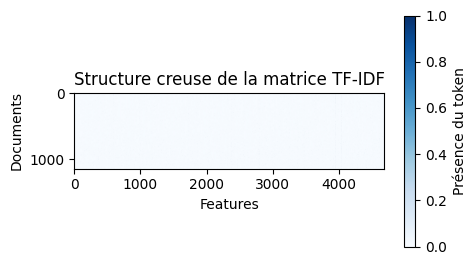

'fifth u high school student use tobacco survey'

In [23]:
# Vectorisation par defaut (lowercase=True)
vectorizer = CountVectorizer()
X = vectorizer.fit_transform([preprocess(t) for t in df.text])

# Affichage des features et du vocabulaire
print("Features :", vectorizer.get_feature_names_out())
print("Tout est converti en minuscules (on peut mettre lowercase=False)\n")

# création du dataframe pour affichage
dfvec = pd.DataFrame(
    data=X.toarray(),  # Utilisation directe de X
    columns=vectorizer.get_feature_names_out()  # get_feature_names_out()
)

print(dfvec)

M_tfidf = X.toarray()
plt.figure(figsize=(5, 3))
plt.imshow(M_tfidf > 0, cmap="Blues")   # bleu = valeur non nulle, gris = zéro
plt.title("Structure creuse de la matrice TF-IDF")
plt.xlabel("Features")
plt.ylabel("Documents")
plt.colorbar(label="Présence du token")
plt.show()
preprocess(df.text[198])

In [24]:
text = [preprocess(t, url=False, hashtags=False, mentions=False) for t in df.text]

# TF-IDF avec normalisation (par défaut)
print("TF-IDF normalisé :\n")

vectorizer_norm = TfidfVectorizer()   # norm='l2' par défaut
X_norm = vectorizer_norm.fit_transform(text)

df_norm = pd.DataFrame(
    X_norm.toarray(),
    columns=vectorizer_norm.get_feature_names_out()
)
print(df_norm)
print()

# Normes des vecteurs normalisés : elles doivent toutes valoir 1
print("Normes L2 avec normalisation (norme = 1 pour chaque document) :")
normes_norm = np.linalg.norm(X_norm.toarray(), axis=1)
print(normes_norm)
print()

# TF-IDF sans normalisation
print("TF-IDF sans normalisation :\n")

vectorizer_raw = TfidfVectorizer(norm=None)   # désactivation explicite
X_raw = vectorizer_raw.fit_transform(text)

df_raw = pd.DataFrame(
    X_raw.toarray(),
    columns=vectorizer_raw.get_feature_names_out()
)
print(df_raw)
print()

# Normes des vecteurs non normalisés
# Chaque document correspond à un vecteur TF-IDF. Sans normalisation,
# leur longueur (norme L2) dépend de la taille et du contenu du document.
print("Normes L2 des vecteurs TF-IDF (sans normalisation) :")
normes_raw = np.linalg.norm(X_raw.toarray(), axis=1)
print(normes_raw)

TF-IDF normalisé :

      aamiin  aap   ab  abah  abc  abdi  abeg  abetz  ability  able  ...  \
0        0.0  0.0  0.0   0.0  0.0   0.0   0.0    0.0      0.0   0.0  ...   
1        0.0  0.0  0.0   0.0  0.0   0.0   0.0    0.0      0.0   0.0  ...   
2        0.0  0.0  0.0   0.0  0.0   0.0   0.0    0.0      0.0   0.0  ...   
3        0.0  0.0  0.0   0.0  0.0   0.0   0.0    0.0      0.0   0.0  ...   
4        0.0  0.0  0.0   0.0  0.0   0.0   0.0    0.0      0.0   0.0  ...   
...      ...  ...  ...   ...  ...   ...   ...    ...      ...   ...  ...   
1135     0.0  0.0  0.0   0.0  0.0   0.0   0.0    0.0      0.0   0.0  ...   
1136     0.0  0.0  0.0   0.0  0.0   0.0   0.0    0.0      0.0   0.0  ...   
1137     0.0  0.0  0.0   0.0  0.0   0.0   0.0    0.0      0.0   0.0  ...   
1138     0.0  0.0  0.0   0.0  0.0   0.0   0.0    0.0      0.0   0.0  ...   
1139     0.0  0.0  0.0   0.0  0.0   0.0   0.0    0.0      0.0   0.0  ...   

      özil  ᴬᴳᴬᴵᴺ  ᴶᴼᴷᴱˢ  ᴸᴵᴱᴰ  ᴸᴼᵛᴱ   ᴼᴺ  ᴼᴼᴴ  ᵀᴴᴵˢ  ᵞᴼᵁ  ᶜᴴᴬᴿᴬᶜᵀᴱ

In [31]:
# y = df["science_related"]

# pipe = Pipeline([
#     ("vectorizer", TfidfVectorizer(lowercase=False, ngram_range=(1, 2))),
#     #("SVM", SVC(kernel="linear"))
#     ("model", LinearSVC())
# ])

# texte = [preprocess(t) for t in df.text]
# X_transformed = pipe.fit(texte, y)

# print("Apprentissage terminé sur l'ensemble du corpus.")

# '''df_pipe = pd.DataFrame(
#     data=X_transformed.toarray(),  # Utilisation directe de X
#     columns=pipe["vectorizer"].get_feature_names_out()
# )'''


# new_review = "salut child labour cancer"
# new_review = preprocess(new_review)

# # Prédiction
# prediction = pipe.predict([new_review])[0]

# print("Avis :", new_review)
# print("Prédiction :", prediction)



# Génération et test du model

In [32]:
y = df["science_related"]
texte = [preprocess(t) for t in df.text]
pipe = Pipeline([
    ("vectorizer", TfidfVectorizer(lowercase=False, ngram_range=(1, 2))),
    #("SVM", SVC(kernel="linear"))
    ("model", LinearSVC())
])

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    texte, y, test_size=0.2, stratify=y, random_state=42
)

params = {
    "model__C": [0.01, 0.1, 1, 5, 10],
    "model__penalty": ["l2"],        # LinearSVC: l1 requires loss='squared_hinge' + dual=False
    "model__loss": ["hinge", "squared_hinge"],
    "model__max_iter": [5000, 10000, 20000], # avoid convergence warnings
    "vectorizer__ngram_range": [(1,1), (1,2), (1,3)],
    "vectorizer__max_features": [3000, 5000, 10000],
    "vectorizer__min_df": [2, 5, 10],
    "vectorizer__max_df": [0.85, 0.95],
}

# If you also want l1, add it as a separate param grid (list of dicts)
params = [
    {   # l2 supports both loss types
        "model__C": [0.01, 0.1, 1, 5, 10],
        "model__penalty": ["l2"],
        "model__loss": ["hinge", "squared_hinge"],
        "model__max_iter": [5000, 10000, 20000],
        "vectorizer__ngram_range": [(1,1), (1,2), (1,3)],
        "vectorizer__max_features": [3000, 5000, 10000],
        "vectorizer__min_df": [2, 5, 10],
        "vectorizer__max_df": [0.85, 0.95],
    },
    {   # l1 only works with squared_hinge + dual=False
        "model__C": [0.01, 0.1, 1, 5, 10],
        "model__penalty": ["l1"],
        "model__loss": ["squared_hinge"],
        "model__dual": [False],
        "model__max_iter": [5000, 10000, 20000],
        "vectorizer__ngram_range": [(1,1), (1,2), (1,3)],
        "vectorizer__max_features": [3000, 5000, 10000],
        "vectorizer__min_df": [2, 5, 10],
        "vectorizer__max_df": [0.85, 0.95],
    }
]

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
grid = GridSearchCV(
    pipe, params,
    cv=cv,
    scoring="f1_weighted",
    return_train_score=True,
    n_jobs=-1
)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
grid.fit(X_train, y_train)
warnings.filterwarnings("default", category=ConvergenceWarning) 

# --- Overfitting diagnosis ---
results = pd.DataFrame(grid.cv_results_)
train_score = results.loc[grid.best_index_, "mean_train_score"]
val_score   = grid.best_score_
gap         = train_score - val_score

print("Meilleurs paramètres :", grid.best_params_)
print(f"Train score:      {train_score:.4f}")
print(f"Validation score: {val_score:.4f}")
print(f"Overfitting gap:  {gap:.4f}", "⚠️ possible overfit" if gap > 0.1 else "✅ looks healthy")

# --- Final evaluation ---
test_score = grid.score(X_test, y_test)
print(f"\nTest score (held-out): {test_score:.4f}")
print(classification_report(y_test, grid.predict(X_test)))

# --- Saving ---
model_path = "ScientificModel.pkl"
with open(model_path, "wb") as f:
    pickle.dump(grid.best_estimator_, f)
print("Modèle sauvegardé dans :", model_path)

Meilleurs paramètres : {'model__C': 1, 'model__loss': 'squared_hinge', 'model__max_iter': 5000, 'model__penalty': 'l2', 'vectorizer__max_df': 0.85, 'vectorizer__max_features': 3000, 'vectorizer__min_df': 2, 'vectorizer__ngram_range': (1, 1)}
Train score:      0.9924
Validation score: 0.7973
Overfitting gap:  0.1951 ⚠️ possible overfit

Test score (held-out): 0.7973
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       153
           1       0.74      0.61      0.67        75

    accuracy                           0.80       228
   macro avg       0.78      0.75      0.77       228
weighted avg       0.80      0.80      0.80       228

Modèle sauvegardé dans : ScientificModel.pkl


# Loading et requête au model

In [39]:
# --- Loading ---
model_path = "ScientificModel.pkl"
with open(model_path, "rb") as f:
    loaded_model = pickle.load(f)

# Indentation fix: move everything OUTSIDE the with block
print("\n--- Post-load diagnosis ---")
train_score_loaded = loaded_model.score(X_train, y_train)
test_score_loaded  = loaded_model.score(X_test, y_test)
gap_loaded         = train_score_loaded - test_score_loaded

print(f"Train score:      {train_score_loaded:.4f}")
print(f"Test score:       {test_score_loaded:.4f}")
print(f"Overfitting gap:  {gap_loaded:.4f}", "⚠️ possible overfit" if gap_loaded > 0.1 else "✅ looks healthy")
print(classification_report(y_test, loaded_model.predict(X_test)))


--- Post-load diagnosis ---
Train score:      0.9923
Test score:       0.8026
Overfitting gap:  0.1897 ⚠️ possible overfit
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       153
           1       0.74      0.61      0.67        75

    accuracy                           0.80       228
   macro avg       0.78      0.75      0.77       228
weighted avg       0.80      0.80      0.80       228



In [ ]:
# --- Prediction ---
new_review = preprocess("do not exist")
prediction = loaded_model.predict([new_review])[0]
print("Avis :", new_review)
print("Prédiction :", "scientific" if prediction else "not scientific")


Avis : exist
Prédiction : not scientific
